This code takes the ET data from OpenET with the mean ET per month from 2020-2025 over each watershed and plots it over time.

In [1]:
import pandas as pd
import numpy as np
import datetime as dt
import matplotlib
import matplotlib.pyplot as plt
import os

In [2]:
#set default font to arial
matplotlib.rc('font',family='Arial')

In [3]:
#inputs
working_directory=r"C:\Users\duffshan\Box\Shannon_Duffy\Writing\Code For Paper Publication"
# filepaths
et_watershed_file=os.path.join(working_directory, "Intermediate Outputs","OpenET Outputs","OpenET_mean_2020_2025_bywatershed.csv")
et_HFF_severity_file=os.path.join(working_directory, "Intermediate Outputs","OpenET Outputs","OpenET_mean_2020_2025_byseverity_HFF.csv")
et_LF_severity_file=os.path.join(working_directory, "Intermediate Outputs","OpenET Outputs","OpenET_mean_2020_2025_byseverity_LF.csv")
et_unburned_file=os.path.join(working_directory, "Intermediate Outputs","OpenET Outputs","OpenET_mean_2020_2025_unburned.csv")
output_folder=os.path.join(working_directory,"Output Data")
output_figures=os.path.join(working_directory,"Output Figures","Intermediate Figures")

In [4]:
et_watershed=pd.read_csv(et_watershed_file)
et_watershed['date']=pd.to_datetime(et_watershed['date'])
et_HFF=pd.read_csv(et_HFF_severity_file)
et_HFF['date']=pd.to_datetime(et_HFF['date'])
et_LF=pd.read_csv(et_LF_severity_file)
et_LF['date']=pd.to_datetime(et_LF['date'])
et_unburned=pd.read_csv(et_unburned_file)
et_unburned['date']=pd.to_datetime(et_unburned['date'])
print(et_watershed)

    Wshed_Name    month       date       mean    stdDev  standard_error  count
0         Mack  2020_01 2020-01-01   7.910627  2.517288        0.036064   4872
1            1  2020_01 2020-01-01   8.443483  1.853526        0.067908    745
2            3  2020_01 2020-01-01   8.061025  1.862785        0.062652    884
3            2  2020_01 2020-01-01   8.830588  1.784222        0.067198    705
4            8  2020_01 2020-01-01   5.725350  1.507234        0.092589    265
..         ...      ...        ...        ...       ...             ...    ...
715          7  2025_12 2025-12-01  10.557313  2.306387        0.162680    201
716          6  2025_12 2025-12-01  11.282262  2.487578        0.189127    173
717         10  2025_12 2025-12-01  15.800775  3.832584        0.322762    141
718          9  2025_12 2025-12-01  13.022128  3.222009        0.310038    108
719    Lookout  2025_12 2025-12-01  14.136137  4.468471        0.016870  70158

[720 rows x 7 columns]


In [26]:
#create function to get annual ET difference from pre-fire mean
def annual_ET_diff(watershed,fireyear):
    watershed_df=pd.DataFrame({"Watershed":watershed},index=[0])
    ws_df=et_watershed[et_watershed['Wshed_Name']==watershed]
    ws_df_pivot=ws_df.pivot_table(values='mean',index="date", columns="Wshed_Name").reset_index()
    ws_df_pivot['year']=ws_df_pivot['date'].dt.year
    prefire=ws_df_pivot[ws_df_pivot['year']<=fireyear]
    #find mean prefire annual ET
    prefire_year=prefire.drop(columns=['date'])
    prefire_annual_sum=prefire_year.groupby('year').agg("sum")
    prefire_annual_average=prefire_annual_sum[watershed].mean()
    for year in ws_df_pivot['year'].unique():
        if year>fireyear:
            df=ws_df_pivot[ws_df_pivot['year']==year]
            year_sum=df[watershed].sum()
            diff_prefire_pctchange=(year_sum-prefire_annual_average)/prefire_annual_average*100
            new_df=pd.DataFrame({"Watershed":watershed,str(year):diff_prefire_pctchange},index=[0])
            watershed_df=pd.merge(watershed_df,new_df,on="Watershed")
    return(watershed_df)


In [27]:
#create table of %change in ET from pre-fire annual mean
ws1_annual=annual_ET_diff("1",2020)
ws2_annual=annual_ET_diff("2",2020)
ws3_annual=annual_ET_diff("3",2020)
ws9_annual=annual_ET_diff("9",2020)
ws10_annual=annual_ET_diff("10",2020)
mack_annual=annual_ET_diff("Mack",2023)
ws8_annual=annual_ET_diff("8",2023)
lookout_annual=annual_ET_diff("Lookout",2023)

annual_df=pd.concat([ws1_annual,ws2_annual,ws3_annual,ws9_annual,ws10_annual,mack_annual,ws8_annual,lookout_annual]).reset_index()
annual_df=annual_df.drop(columns=["index"])
print(annual_df)

  Watershed      2021       2022       2023       2024       2025
0         1  0.092389  -9.963468  -1.335243   0.202708   1.601645
1         2  2.913412  -7.434938   0.852741   0.528244   2.661883
2         3  6.075384  -5.434373   3.104472   3.191239   3.965108
3         9 -2.313505 -12.595320 -10.105990  -7.580424  -4.883630
4        10  5.225242  -5.828379   2.191349   2.528900   3.683643
5      Mack       NaN        NaN        NaN -17.122756 -16.599704
6         8       NaN        NaN        NaN   0.878649   4.720754
7   Lookout       NaN        NaN        NaN  -8.657072  -6.353994


In [25]:
#export to csv
output_path = os.path.join(output_folder, "change_in_annual_ET.csv")
annual_df.to_csv(output_path, index=False)

In [67]:
#create function to get monthly ET difference from pre-fire mean
def monthly_ET_diff(watershed,fireyear):
    watershed_df=pd.DataFrame({"month":[1,2,3,4,5,6,7,8,9,10,11,12]})
    ws_df=et_watershed[et_watershed['Wshed_Name']==watershed]
    ws_df_pivot=ws_df.pivot_table(values='mean',index="date", columns="Wshed_Name").reset_index()
    ws_df_pivot['year']=ws_df_pivot['date'].dt.year
    ws_df_pivot['month']=ws_df_pivot['date'].dt.month
    prefire=ws_df_pivot[ws_df_pivot['year']<=fireyear]
    prefire=prefire.drop(columns=['date','year'])
    prefire_monthly_means=prefire.groupby('month').agg("mean")
    prefire_monthly_means['month']=prefire_monthly_means.index
    for year in ws_df_pivot['year'].unique():
        if year>fireyear:
            year_df=pd.DataFrame()
            df=ws_df_pivot[ws_df_pivot['year']==year]
            for month in range(1,13):
                prefire_value=prefire_monthly_means.loc[prefire_monthly_means['month']==month,watershed].values[0]
                postfire_year_value=df.loc[df['month']==month,watershed].values[0]
                pct_change=(postfire_year_value-prefire_value)/prefire_value*100
                # print(year, month, pct_change)
                month_df=pd.DataFrame({"month":month,str(year):pct_change},index=[0])
                year_df=pd.concat([year_df,month_df])
            watershed_df=pd.merge(watershed_df,year_df,on="month")
    return watershed_df
                    
ws1_monthly=monthly_ET_diff("1",2020)
ws2_monthly=monthly_ET_diff("2",2020)
ws3_monthly=monthly_ET_diff("3",2020)
ws9_monthly=monthly_ET_diff("9",2020)
ws10_monthly=monthly_ET_diff("10",2020)
mack_monthly=monthly_ET_diff("Mack",2023)
ws8_monthly=monthly_ET_diff("8",2023)
lookout_monthly=monthly_ET_diff("Lookout",2023)

monthly_df_list=[ws1_monthly,ws2_monthly,ws3_monthly,ws9_monthly,ws10_monthly,mack_monthly,ws8_monthly,lookout_monthly]
watershed_names=["ws1","ws2","ws3","ws9","ws10","mack","ws8","lookout"]

In [68]:
#export to csv
for i in range(len(monthly_df_list)):
    df=monthly_df_list[i]
    output_path = os.path.join(output_folder, f"{watershed_names[i]}_change_in_monthly_ET.csv")
    df.to_csv(output_path, index=False)

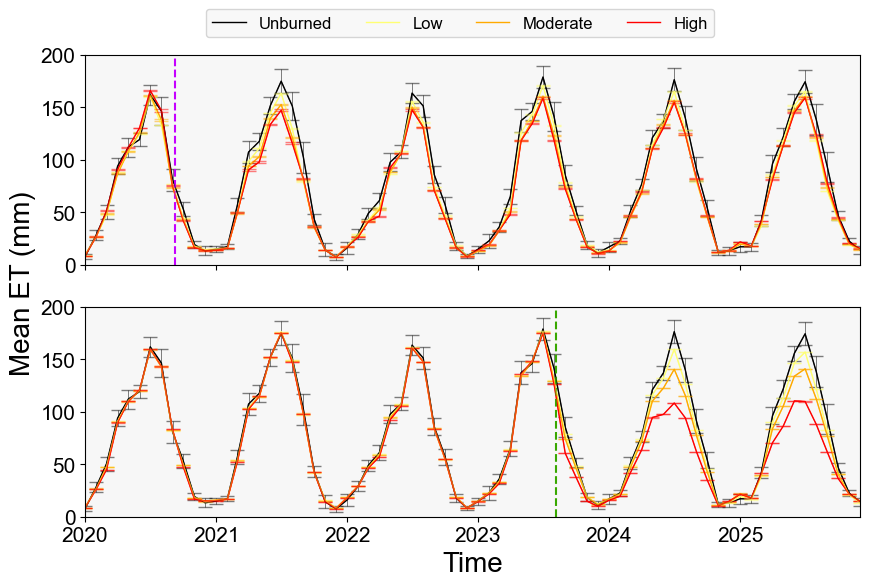

In [70]:
fig,axs = plt.subplots(2,1, sharex=True,figsize=(10,6))
plt.xlabel("Time",fontsize=20)
fig.supylabel("Mean ET (mm)", fontsize=20, x=0.05)
plt.xlim(pd.to_datetime("01-01-2020"),pd.to_datetime("12-01-2025"))
axs[0].set_ylim(0,200)
axs[1].set_ylim(0,200)
plt.xticks(fontsize=15)
axs[0].set_facecolor('#F7F7F7')
axs[1].set_facecolor('#F7F7F7')
axs[0].tick_params(axis='y', which='major', labelsize=15)
axs[1].tick_params(axis='y', which='major', labelsize=15)
axs[0].plot(et_unburned['date'],et_unburned['mean'],color="black",linewidth=1,label="Unburned")
axs[0].errorbar(et_unburned['date'],et_unburned['mean'],yerr=et_unburned['stdDev'],color="black",linewidth=0.7,capsize=5,alpha=0.5)
axs[1].plot(et_unburned['date'],et_unburned['mean'],color="black",linewidth=1)
axs[1].errorbar(et_unburned['date'],et_unburned['mean'],yerr=et_unburned['stdDev'],color="black",linewidth=0.7,capsize=5,alpha=0.5)
for severity in [1,2,3]:
    severity_df_HFF=et_HFF[et_HFF['gridcode']==severity]
    if severity ==1:
        axs[0].plot(severity_df_HFF['date'],severity_df_HFF['mean'],label="Low",color="#FFFF73",linewidth=1)
        axs[0].errorbar(severity_df_HFF['date'],severity_df_HFF['mean'],yerr=severity_df_HFF['standard_error'],color="#FFFF73",linewidth=0.7,capsize=5,alpha=0.5)
    elif severity ==2:
        axs[0].plot(severity_df_HFF['date'],severity_df_HFF['mean'],label="Moderate",color="#FFAA00",linewidth=1)
        axs[0].errorbar(severity_df_HFF['date'],severity_df_HFF['mean'],yerr=severity_df_HFF['standard_error'],color="#FFAA00",linewidth=0.7,capsize=5,alpha=0.5)
    elif severity ==3:
        axs[0].plot(severity_df_HFF['date'],severity_df_HFF['mean'],label="High",color="#FF0000",linewidth=1)
        axs[0].errorbar(severity_df_HFF['date'],severity_df_HFF['mean'],yerr=severity_df_HFF['standard_error'],color="#FF0000",linewidth=0.7,capsize=5,alpha=0.5)
    else:
        continue
    severity_df_LF=et_LF[et_LF['gridcode']==severity]
    if severity ==1:
        axs[1].plot(severity_df_LF['date'],severity_df_LF['mean'],color="#FFFF73",linewidth=1)
        axs[1].errorbar(severity_df_LF['date'],severity_df_LF['mean'],yerr=severity_df_LF['standard_error'],color="#FFFF73",linewidth=0.7,capsize=5,alpha=0.5)
    elif severity ==2:
        axs[1].plot(severity_df_LF['date'],severity_df_LF['mean'],color="#FFAA00",linewidth=1)
        axs[1].errorbar(severity_df_LF['date'],severity_df_LF['mean'],yerr=severity_df_LF['standard_error'],color="#FFAA00",linewidth=0.7,capsize=5,alpha=0.5)
    elif severity ==3:
        axs[1].plot(severity_df_LF['date'],severity_df_LF['mean'],color="#FF0000",linewidth=1)
        axs[1].errorbar(severity_df_LF['date'],severity_df_LF['mean'],yerr=severity_df_LF['standard_error'],color="#FF0000",linewidth=0.7,capsize=5,alpha=0.5)
    else:
        continue
axs[0].axvline(pd.to_datetime("09-07-2020"),color="#C500FF",linestyle="dashed")
axs[1].axvline(pd.to_datetime("08-05-2023"),color="#38A800",linestyle="dashed")
fig.legend(loc="upper center",fontsize=12,ncols=4,bbox_to_anchor=(0.5,0.97), facecolor='#F7F7F7')
plt.show()
output_path = os.path.join(output_figures, f"ET_timeseries_burn_severity.png")
fig.savefig(output_path,bbox_inches='tight')